<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
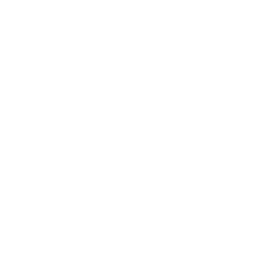
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Teleliikenteen asiakaspoistuman alttiuspisteytys</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Teleliikenne / Asiakaspysyvyys &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Asiakkaan päätös lähteä on harvoin yllätys — varoitusmerkit kertyvät laskutus- ja tukihistoriaan kauan ennen kuin liittymä sammuu. Tämä muistikirja rakentaa **poistuma-alttiusmallin** matkapuhelinasiakaskunnalle käyttäen **PROC LOGISTIC** -proseduuria, ja muuttaa sitten sovitetut todennäköisyydet järjestetyksi säilyttämistoimenpidelistaksi.

Mallinnamme binäärisen 6 kuukauden poistumalopputuloksen suhteessa asiakassuhteen kestoon, kuukausimaksuun, tukipyyntöjen määrään, jäljellä olevaan sopimusaikaan, myöhästyneiden maksujen historiaan, tyytyväisyyteen ja hinnoittelupakettiin. Sovitettu malli **erottelee poistuneet pysyneistä c-tilastoluvulla (ROC-käyrän alle jäävä pinta-ala) 0,878**, ja se on **hyvin kalibroitu** (Hosmer-Lemeshow p = 0,94). Kaksi käyttäytymissignaalia hallitsee: **jokainen lisätukipyyntö nostaa poistuman vetosuhdetta 2,19-kertaiseksi** (95 %:n luottamusväli 1,28-3,73), kun taas **jokainen tyytyväisyyspisteen nousu puolittaa vetosuhteen suunnilleen** (vetosuhde 0,51, 95 %:n luottamusväli 0,28-0,92). Asiakkaiden järjestäminen ennustetun todennäköisyyden mukaan ja jakaminen neljään säilyttämisluokkaan keskittää riskin voimakkaasti: ylin *KIIREELLINEN*-luokka kantaa **67 %:n havaitun poistuman** kun taas ***SEURANTA*-luokassa se on alle 4 %**, mikä antaa säilyttämistiimille perustellun tavan käyttää rajallista säilyttämisbudjettia sinne, missä sillä on merkitystä.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|---------|
| WORK.SUBSCRIBERS | Synteettinen matkapuhelinasiakaskunta, jolla on 6 kuukauden poistumalippu | 100 |

Aineisto luodaan muistikirjan sisällä tunnetusta logistisesta datan generointiprosessista, joten jokainen alla näytetty kerroin ja todennäköisyys on toistettavissa. Tämä ympäristö ajaa Jenneriä lisenssittömässä tilassa, joka rajoittaa syötteen **100 havaintoon** — analyysi on mitoitettu tämän budjetin mukaan sen sijaan, että käytettäisiin tuotantopisteytysajon suurempaa asiakaskantaa.

---

In [1]:
/* --------------------------------------------------------
   Luodaan synteettinen teleliikenteen asiakaskunta.
   Binäärinen lopputulos: churn = 1, jos asiakas lähti
   kuuden kuukauden sisällä, muuten 0. Riski perustuu
   logistiseen malliin, joten myöhempi sovitus pohjautuu
   tunnettuun signaaliin.
   -------------------------------------------------------- */
TIEDOT work.subscribers;
    CALL streaminit(7);
    TAULUKKO plan_list[4] $12 _temporary_
        ('BASIC' 'STANDARD' 'PREMIUM' 'UNLIMITED');
    TEE customer_id = 1 ASTI 100;
        plan_idx  = int(rand('uniform') * 4) + 1;
        plan_type = plan_list[plan_idx];

        tenure_months = int(rand('exponential') * 18) + 1;
        JOS tenure_months > 72 NIIN tenure_months = 72;

        monthly_charge = round(rand('normal', 65, 20), 0.01);
        JOS monthly_charge < 20 NIIN monthly_charge = 20;

        num_support_calls = int(rand('poisson', 2.2));
        JOS num_support_calls > 12 NIIN num_support_calls = 12;

        contract_remaining_mo = int(rand('uniform') * 24);

        late_payments_12mo = int(rand('poisson', 0.7));

        satisfaction_score = round(rand('normal', 6.5, 1.6), 0.1);
        JOS satisfaction_score < 1  NIIN satisfaction_score = 1;
        JOS satisfaction_score > 10 NIIN satisfaction_score = 10;

        /* Todellinen churnin log-odds (mallin palauttama alla) */
        eta = 2.5
            - 0.05 * tenure_months
            + 0.45 * num_support_calls
            - 0.10 * contract_remaining_mo
            + 0.55 * late_payments_12mo
            - 0.65 * satisfaction_score
            + 0.90 * (plan_type = 'BASIC');
        p_churn = 1 / (1 + EXP(-eta));

        churn = (rand('uniform') < p_churn);
        PITUUS churn_label $10;
        JOS churn NIIN churn_label = 'LÄHTENYT';
        MUUTEN churn_label = 'PYSYNYT';
        TULOSTE;
    LOPPU;
    POISTA plan_idx eta p_churn;
SUORITA;


NOTE: DATA work.subscribers


NOTE: Wrote work.subscribers (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

### Ketkä lähtevät? Ensimmäinen katsaus

Ennen mallintamista profiloimme asiakaskunnan. PROC FREQ näyttää raa'an poistumaprosentin hinnoittelupaketeittain, ja PROC MEANS vertailee poistuneiden ja pysyneiden asiakkaiden keskimääräisiä profiileja.

                                       Poistumaprosentti hinnoittelupaketeittain                                        

                                                   The FREQ Procedure

Table of Pakettityyppi by Poistuma

Pakettityyppi |  LÄHTENYT |   PYSYNYT |      Total
--------------+-----------+-----------+-----------
BASIC         |         5 |        25 |         30
--------------+-----------+-----------+-----------
PREMIUM       |         3 |        19 |         22
--------------+-----------+-----------+-----------
STANDARD      |         5 |        21 |         26
--------------+-----------+-----------+-----------
UNLIMITED     |         3 |        19 |         22
--------------+-----------+-----------+-----------
Total         |        16 |        84 |        100

                                    Keskimääräinen asiakasprofiili poistuman mukaan                                     

                                                  The MEANS Procedure

                


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_plan_type_churn_label.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


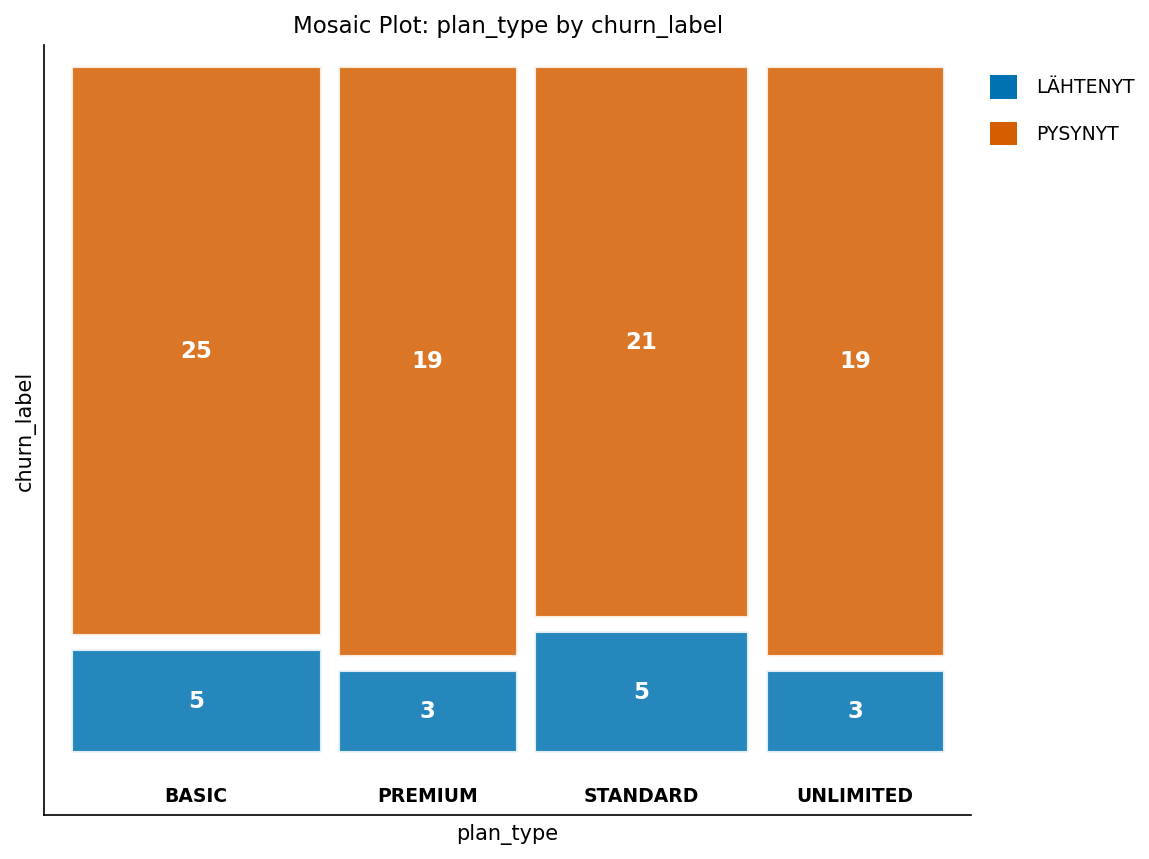

In [2]:
/* --------------------------------------------------------
   Perustason poistumaprosentti hinnoittelupaketeittain ja
   keskimääräinen asiakasprofiili lopputuloksen mukaan
   jaettuna.
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.subscribers;
    TABLES plan_type * churn_label / nocol nopercent;
    NIMIKE plan_type='Pakettityyppi' churn_label='Poistuma';
    OTSIKKO 'Poistumaprosentti hinnoittelupaketeittain';
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.subscribers n mean std;
    LUOKKA churn_label;
    MUUTTUJA tenure_months monthly_charge num_support_calls
        late_payments_12mo satisfaction_score;
    NIMIKE churn_label='Poistuma' tenure_months='Asiakassuhteen kesto (kk)'
          monthly_charge='Kuukausimaksu ($)' num_support_calls='Tukipyynnöt'
          late_payments_12mo='Myöhästyneet maksut (12kk)'
          satisfaction_score='Tyytyväisyyspisteet';
    OTSIKKO 'Keskimääräinen asiakasprofiili poistuman mukaan';
SUORITA;

---

### Poistuma-alttiusmallin sovittaminen

PROC LOGISTIC regressoi binäärisen poistumalipun käyttäytymis- ja tilimuuttujien suhteen.
`event='1'` kertoo proseduurille, että mallinnetaan poistumisen todennäköisyyttä. Hinnoittelupaketti tulee mukaan CLASS-muuttujana, jonka referenssitasona on *UNLIMITED*, joten kunkin paketin vetosuhde luetaan suhteessa premium-tasoon. Pyydämme R²-sovitustunnuslukuja, ja ROC-käyrä sekä vetosuhdekuvaaja tuotetaan ODS-grafiikkana.

                                          Teleliikenteen poistuma-alttiusmalli                                          

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
    Probability modeled is churn='1'    

Ordered Value  churn     Total Frequency
-------------  --------  ---------------
            1  0                      84
            2  1                      16

                 Class Level Information                 

Class            Levels  Values                          
-------------  --------  --------------------------------
Pakettityyppi         4  BASIC PREMIUM STANDARD UNLIMITED

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: churn

Criterion     Value
---------  --------
AIC          75


NOTE: PROC LOGISTIC data=work.subscribers

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: Output dataset work.scored written with 100 observations.
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: ODS plot written: logistic_roc.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json


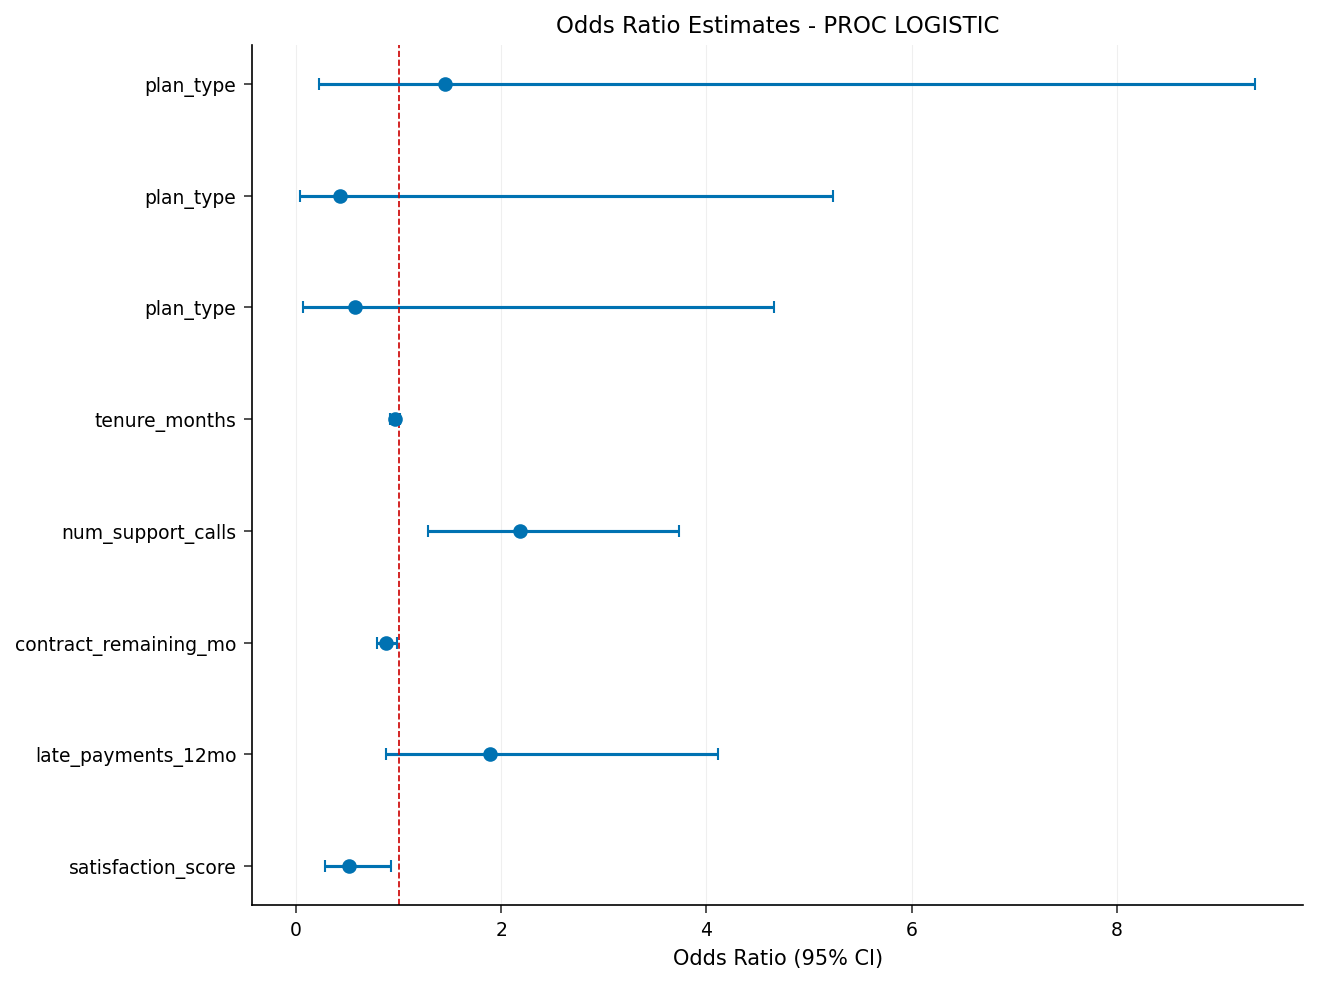

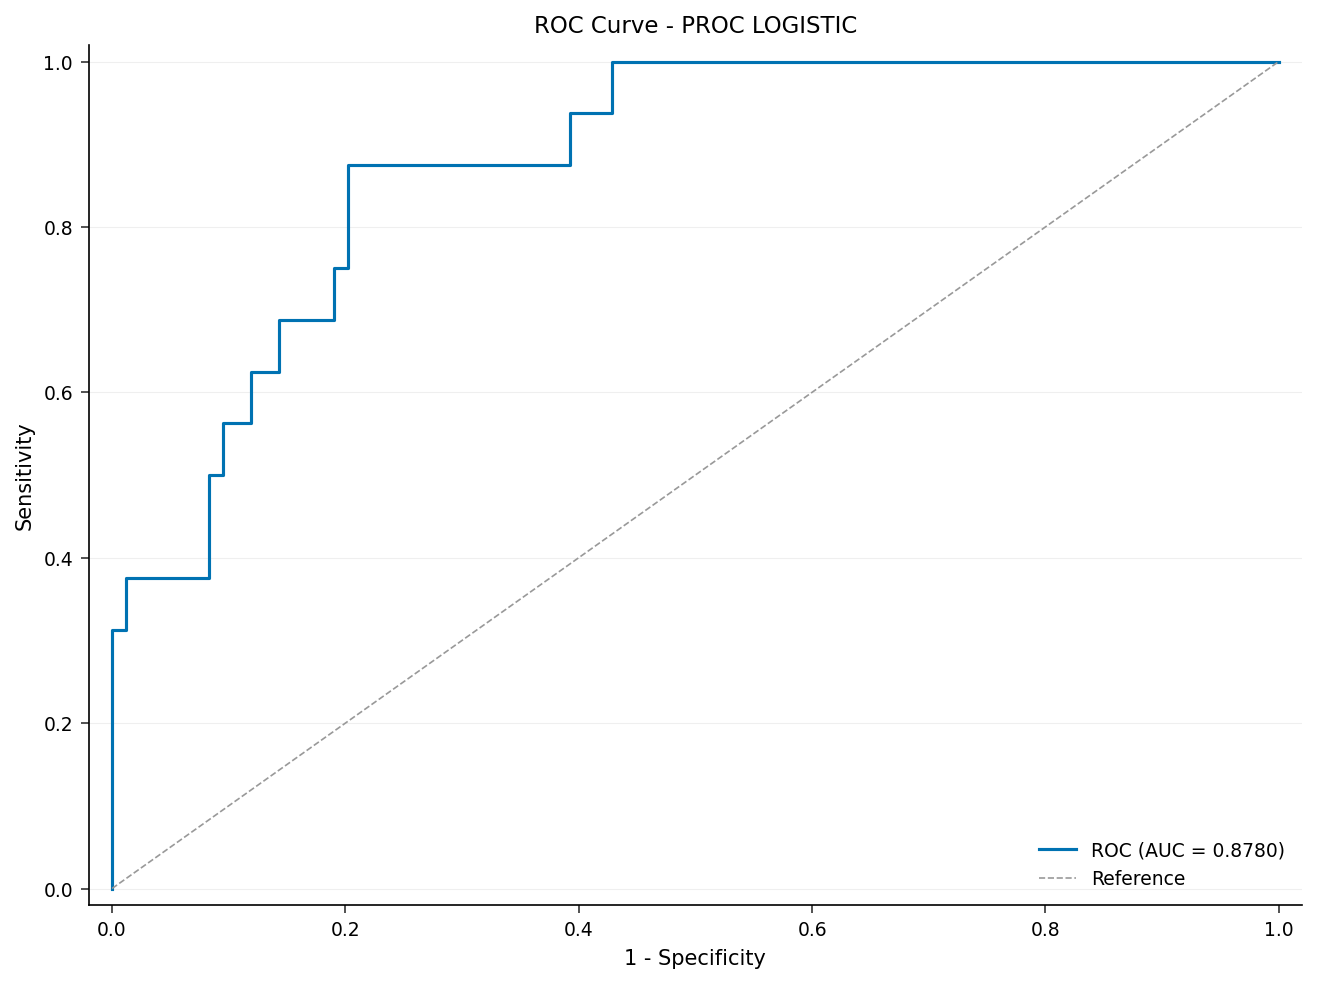

In [3]:
/* --------------------------------------------------------
   Binäärinen poistuma-alttiusmalli. Vetosuhteet (odds
   ratio) kvantifioivat kunkin ajurin vaikutuksen; ROC-käyrä
   ja sen pinta-ala (c-tilastoluku) mittaavat, kuinka hyvin
   ennustettu riski erottaa poistuneet pysyneistä.
   predicted=churn_prob kirjoittaa sovitetun todennäköisyyden
   myöhempää luokittelua varten.
   -------------------------------------------------------- */
PROSEDUURI LOGISTIC TIEDOT=work.subscribers PLOTS(only)=(roc oddsratio);
    LUOKKA plan_type (REF='UNLIMITED') / PARAM=REF;
    MODEL churn(EVENT='1') = plan_type
                             tenure_months
                             num_support_calls
                             contract_remaining_mo
                             late_payments_12mo
                             satisfaction_score
        / rsquare;
    NIMIKE plan_type='Pakettityyppi' tenure_months='Asiakassuhteen kesto (kk)'
          num_support_calls='Tukipyynnöt' contract_remaining_mo='Sopimusaikaa jäljellä (kk)'
          late_payments_12mo='Myöhästyneet maksut (12kk)'
          satisfaction_score='Tyytyväisyyspisteet';
    TULOSTE out=work.scored predicted=churn_prob;
    OTSIKKO 'Teleliikenteen poistuma-alttiusmalli';
SUORITA;

### Kuinka hyvin malli luokittelee?

Malli on hyödyllinen säilyttämisen kannalta vain, jos ennustetut todennäköisyydet erottelevat asiakkaat, jotka todella lähtevät. Alla oleva luokittelutaulukko laskee oikeat ja väärät luokittelut 0,50 todennäköisyyden katkaisurajalla, ja Hosmer-Lemeshow-testi tarkistaa, että ennustettu riski vastaa havaittua riskiä koko todennäköisyysalueella (suuri p-arvo osoittaa hyvää kalibrointia).

                                               Luokittelu ja kalibrointi                                                

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
    Probability modeled is churn='1'    

Ordered Value  churn     Total Frequency
-------------  --------  ---------------
            1  0                      84
            2  1                      16

                 Class Level Information                 

Class            Levels  Values                          
-------------  --------  --------------------------------
Pakettityyppi         4  BASIC PREMIUM STANDARD UNLIMITED

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: churn

Criterion     Value
---------  --------
AIC          75


NOTE: PROC LOGISTIC data=work.subscribers

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: ODS plot written: logistic_roc.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json


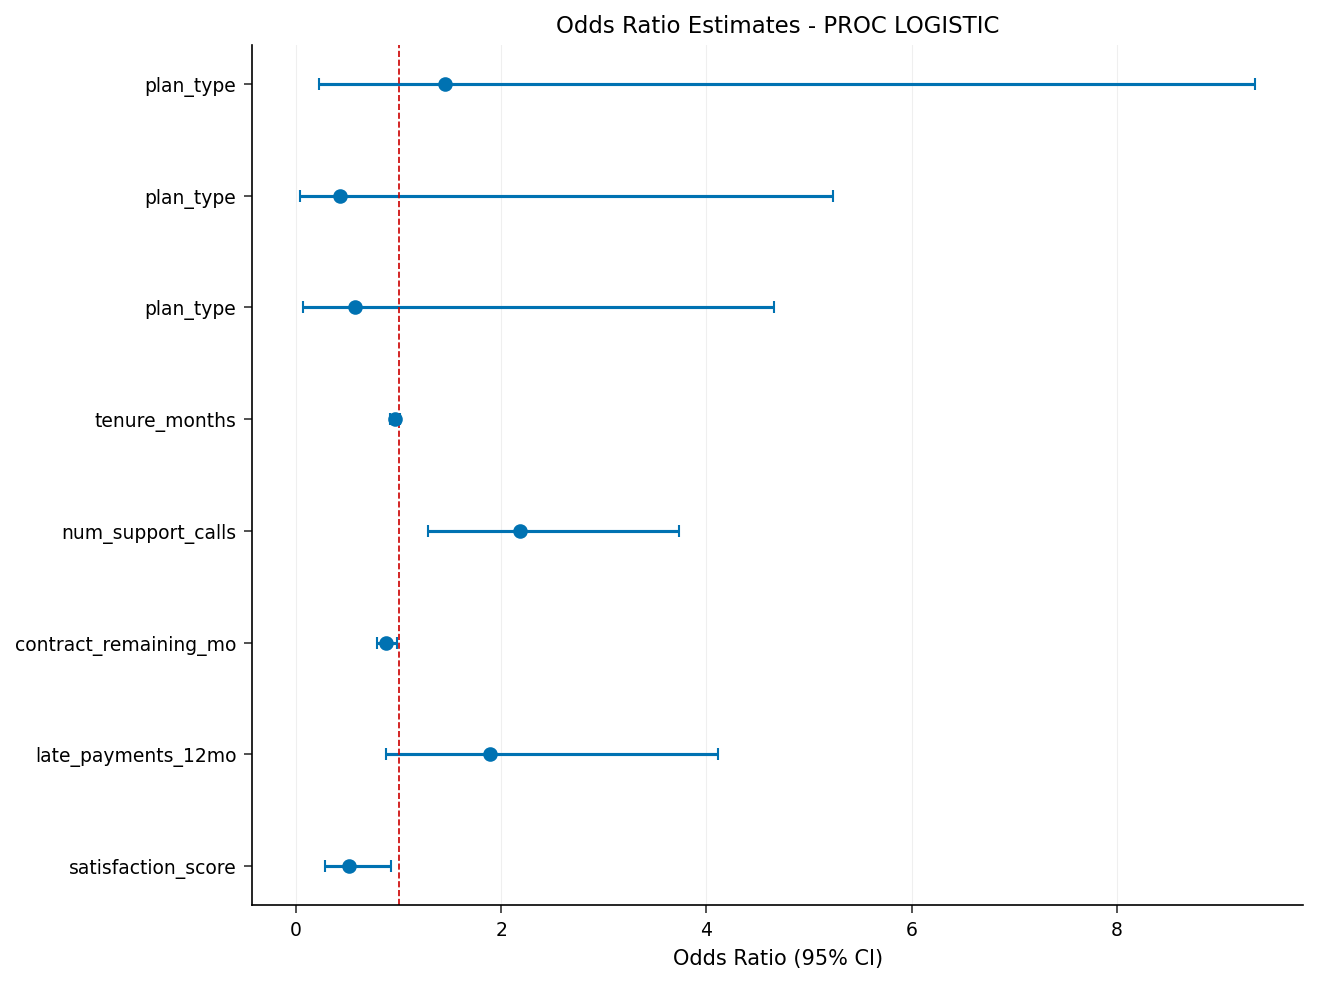

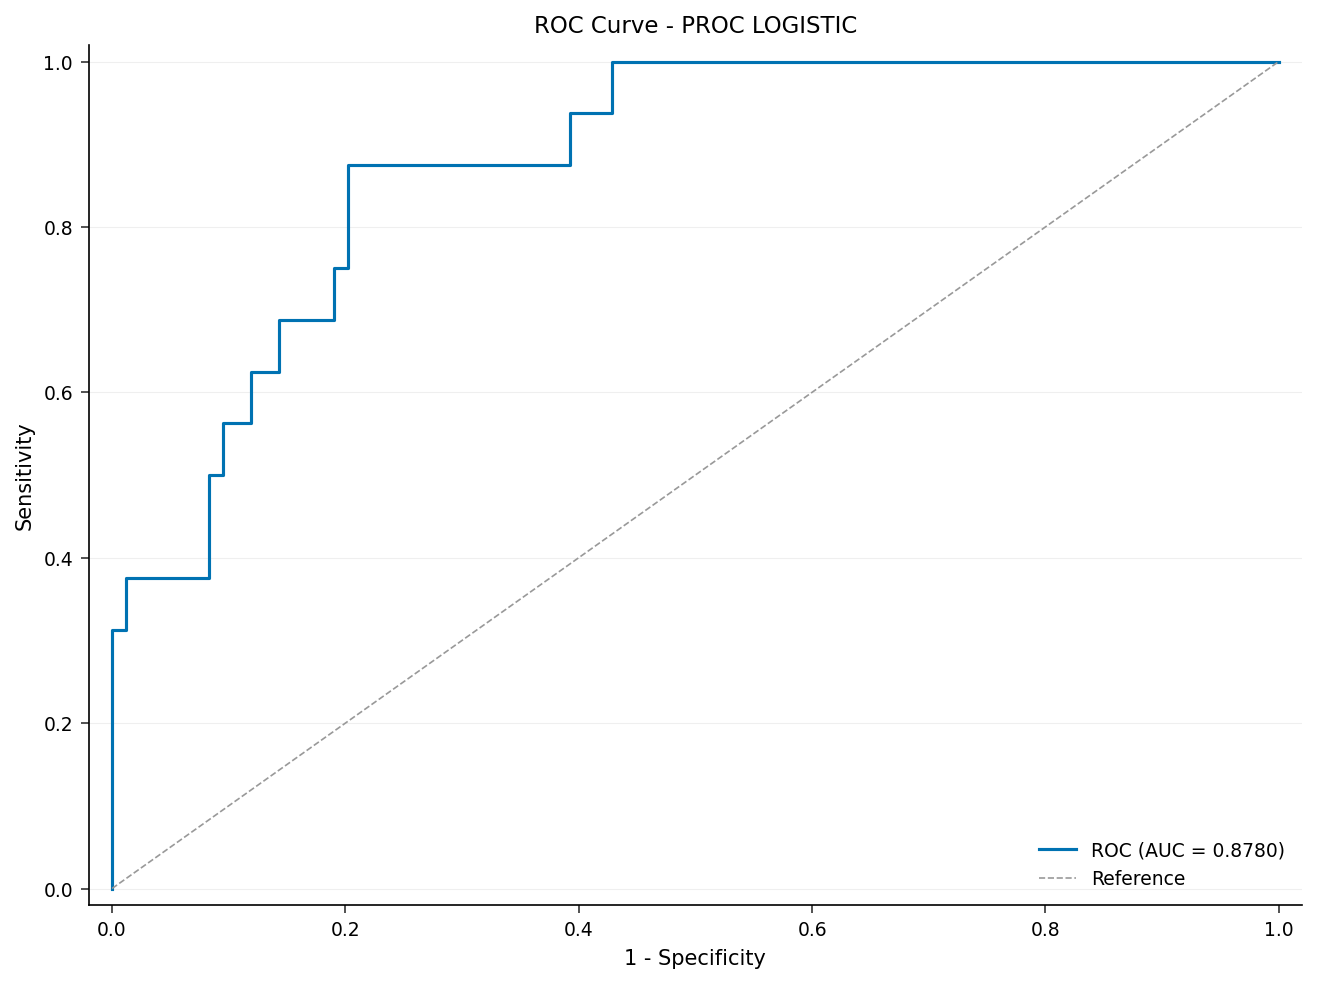

In [4]:
/* --------------------------------------------------------
   Luokittelutarkkuus 0,50 katkaisurajalla sekä
   Hosmer-Lemeshow-yhteensopivuustesti (kalibrointi).
   -------------------------------------------------------- */
PROSEDUURI LOGISTIC TIEDOT=work.subscribers;
    LUOKKA plan_type (REF='UNLIMITED') / PARAM=REF;
    MODEL churn(EVENT='1') = plan_type
                             tenure_months
                             num_support_calls
                             contract_remaining_mo
                             late_payments_12mo
                             satisfaction_score
        / ctable pprob=0.5 lackfit;
    NIMIKE plan_type='Pakettityyppi' tenure_months='Asiakassuhteen kesto (kk)'
          num_support_calls='Tukipyynnöt' contract_remaining_mo='Sopimusaikaa jäljellä (kk)'
          late_payments_12mo='Myöhästyneet maksut (12kk)'
          satisfaction_score='Tyytyväisyyspisteet';
    OTSIKKO 'Luokittelu ja kalibrointi';
SUORITA;

---

### Todennäköisyyksistä säilyttämistoimenpidelistaksi

Sovitetusta todennäköisyydestä tulee operatiivinen työkalu, kun se jaetaan toimenpideluokkiin. Järjestämme asiakkaat suurimmasta pienimpään poistumariskiin ja jaamme kunkin yhteen neljästä säilyttämisluokasta, minkä jälkeen validoimme rajakohdat taulukoimalla *todellisen* poistumalopputuloksen kunkin luokan sisällä.

                                        Havaittu poistuma säilyttämisluokittain                                         

                                                   The FREQ Procedure

Table of Toimenpideluokka by Poistuma

Toimenpideluokka |  LÄHTENYT |   PYSYNYT |      Total
-----------------+-----------+-----------+-----------
KESKITASO        |         5 |        22 |         27
-----------------+-----------+-----------+-----------
KIIREELLINEN     |         6 |         3 |          9
-----------------+-----------+-----------+-----------
KORKEA           |         3 |         6 |          9
-----------------+-----------+-----------+-----------
SEURANTA         |         2 |        53 |         55
-----------------+-----------+-----------+-----------
Total            |        16 |        84 |        100




NOTE: DATA work.retention_list


NOTE: Read 100 rows from work.scored.
NOTE: Wrote work.retention_list (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_retention_action_churn_label.spec.json
NOTE: PROC FREQ statement used.


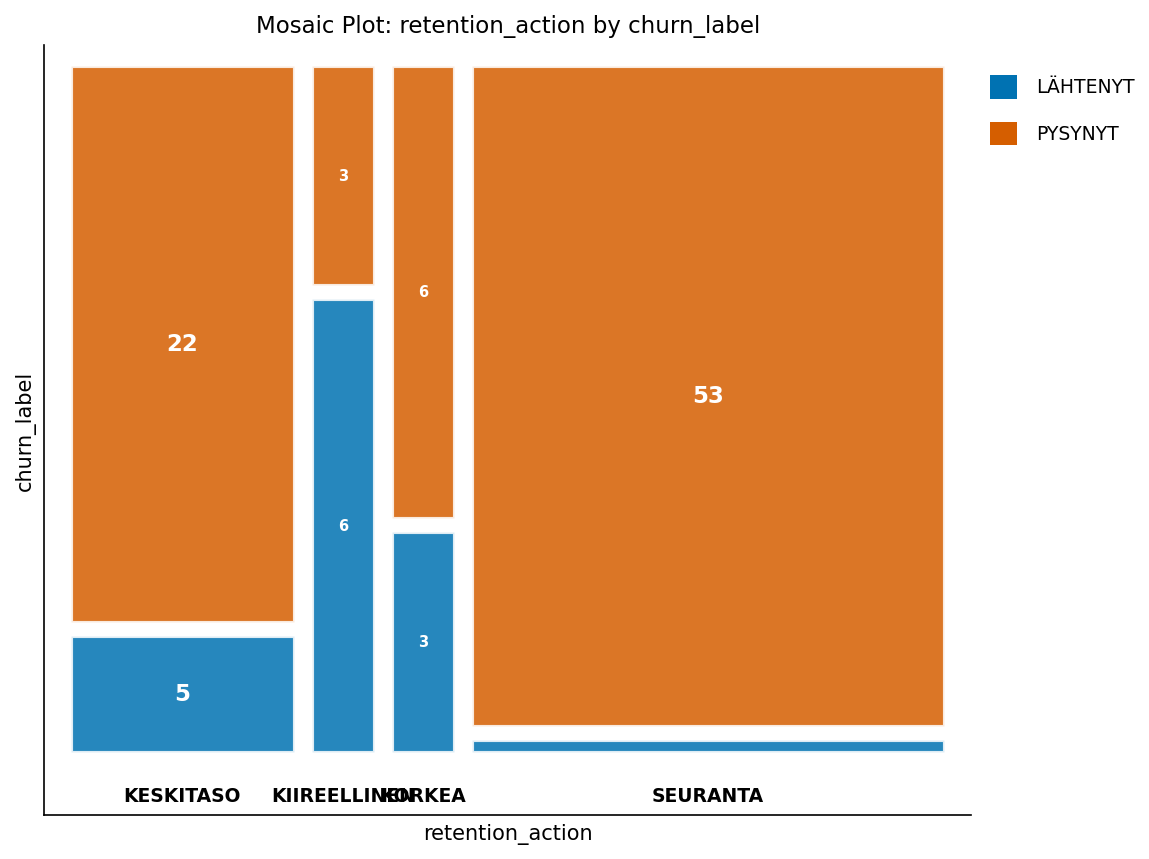

In [5]:
/* --------------------------------------------------------
   Määritetään säilyttämistoimenpideluokka ennustetun
   poistumatodennäköisyyden perusteella, ja validoidaan
   rajakohdat havaitun lopputuloksen avulla.
   -------------------------------------------------------- */
TIEDOT work.retention_list;
    ASETA work.scored;
    PITUUS retention_action $14;
    JOS      churn_prob >= 0.50 NIIN retention_action = 'KIIREELLINEN';
    MUUTEN JOS churn_prob >= 0.25 NIIN retention_action = 'KORKEA';
    MUUTEN JOS churn_prob >= 0.10 NIIN retention_action = 'KESKITASO';
    MUUTEN                            retention_action = 'SEURANTA';
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.retention_list;
    TABLES retention_action * churn_label / nocol nopercent;
    NIMIKE retention_action='Toimenpideluokka' churn_label='Poistuma';
    OTSIKKO 'Havaittu poistuma säilyttämisluokittain';
SUORITA;

### Tulkinta

Malli tunnistaa selkeän ja operatiivisesti hyödyllisen poistumasignaalin 100 asiakkaan otoksesta.

**Erottelukyky ja kalibrointi.** ROC-käyrän pinta-ala on **0,878**, mikä tarkoittaa, että satunnaisesti valitulle poistuneen ja pysyneen asiakkaan parille malli antaa poistuneelle korkeamman riskin noin 88 % ajasta — vahva erottelukyky. Hosmer-Lemeshow-testi on mukavasti ei-merkitsevä (khiin neliö = 2,88, vapausasteita 8, **p = 0,94**), joten ennustettu riski seuraa havaittua riskiä hyvin; McFadden-R² on 0,26 (maksimiskaalattu 0,45).

**Mikä ajaa poistumaa.** Kaksi vaikutusta ylittää tilastollisen merkitsevyyden ja ovat linjassa säilyttämisintuition kanssa. **Tukipyyntöjen määrä** on voimakkain käyttäytymiseen liittyvä varoitusmerkki — jokainen lisäpyyntö kertoo poistuman vetosuhdetta **2,19**-kertaiseksi (95 %:n luottamusväli 1,28-3,73, p = 0,004). **Tyytyväisyys** on peilikuva tästä: jokainen pisteen nousu 1-10-asteikolla laskee poistuman vetosuhteen arvoon **0,51** (95 %:n luottamusväli 0,28-0,92, p = 0,025). **Jäljellä oleva sopimusaika** on lievästi suojaava (vetosuhde 0,88 kuukautta kohden, p = 0,028), mikä on linjassa vaihtamisen kitkan kanssa. Asiakassuhteen kesto, kuukausimaksu, myöhästyneet maksut ja hinnoittelupaketti eivät saavuta merkitsevyyttä tässä otoskoossa, vaikka niiden piste-estimaatit kallistuvat odotettuun suuntaan (pidempi asiakassuhde ja *UNLIMITED*-paketti ovat suojaavia).

**Riskin muuttaminen toimenpiteiksi.** Sovitettujen todennäköisyyksien jakaminen luokkiin tuottaa voimakkaasti kerrostuneen toimenpidelistan. Niistä 16 asiakkaasta, jotka todella poistuivat, **9 (56 %) osuu kahteen ylimpään luokkaan**, ja **KIIREELLINEN-luokan havaittu poistumaprosentti on 67 %** (6/9), kun se merkitsee vain 9 % koko asiakaskunnasta. Toisessa ääripäässä **SEURANTA-luokka — 55 % asiakkaista — poistuu alle 4 %:n tahdilla** (2/55), joten säilyttämistiimi voi turvallisesti jättää sen vähemmälle huomiolle. Tämä on alttiusmallin käytännön hyöty: se antaa kiinteän säilyttämisbudjetin jahdata todennäköisimmin lähteviä asiakkaita sen sijaan, että kulutus jaettaisiin tasaisesti koko asiakaskuntaan.

---

In [6]:
/* --------------------------------------------------------
   Viedään järjestetty säilyttämistoimenpidelista kampanjan-
   hallintajärjestelmää varten: suurin poistumariski ensin.
   -------------------------------------------------------- */
PROSEDUURI LAJITTELE TIEDOT=work.retention_list;
    MUKAAN LASKEVA churn_prob;
SUORITA;

PROSEDUURI VIE TIEDOT=work.retention_list
    OUTFILE='churn_retention_list.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC SORT data=work.retention_list

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.retention_list.
NOTE: Wrote work.retention_list (100 rows, 13 columns).
NOTE: PROC SORT statement used.
NOTE: PROC EXPORT data=work.retention_list outfile=churn_retention_list.csv

NOTE: Exported 100 rows to churn_retention_list.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>